# Tutorial: Making image cutouts from the data volume - start from scratch

<br>
<br>

<img style="position: absolute; right: 60px; top: 40px; height: 160px; width: 160px" src="https://datalabs.esa.int/datalab-icon/c11e47af-7ce9-4281-b3b5-475a180a256f" /> 

**Author(s):** Héctor Cánovas Cabrera

**Last modified:** 2026-05-22

**Notebook summary**

This example notebook presents several example use cases for making cutouts of Euclid mosaic images - to learn how to obtain cutouts from calibrated frames please see the "\_v2" version of this notebook) from a data volume on ESA Datalabs.
It is fully compatible with the IDR enviroment (compatibility with PDR, REG and OTF will be added soon).
In this tutorial, you will learn how to create MOSAIC cutouts associated to:

1. ... one source observed multiple times in the EDF: it shows how to associate an observation time to each MER entry.
2. ... a list of SIMBAD sources included in the DEEP survey
2. ... a list of sources extracted from the MER (DEEP) catalogue.


**Useful links:**

* [Euclid IDR Help pages: Catalogues](https://euclid.dataspace.esa.int/internal-archive-help/Data_products__catalogues.html)
* [Q1 data release homepage](https://www.cosmos.esa.int/en/web/euclid/euclid-q1-data-release)
* [IDR1 data release homepage](https://www.cosmos.esa.int/web/euclid/euclid-dr1)
* [Euclid Q1 data product description](https://euclid.esac.esa.int/dr/q1/dpdd/index.html)
* [Euclid IDR1 data product description](http://st-dm.pages.euclid-sgs.uk/data-product-doc/dm10/)
* [Euclid Astroquery documentation](https://astroquery.readthedocs.io/en/latest/esa/euclid/euclid.html)


**Key TAP tables:**

The "dr1.mosaic_product" ([TAP](https://www.ivoa.net/Documents/TAP/20190927/)) table contains the metadata required to locate the observations (images) stored in the Multi-Extension FITS (MEF) files. The relevant fields that define how to access the images associated to a given source are the "fov" (the field that contains the observation footprint), and the "datalabs_path" and "file_name" fields.

**Related ADQL queries:**

In the example query below, the [INTERSECTS](https://www.ivoa.net/Documents/ADQL/20231215/REC-ADQL-2.1.html#tth_sEc4.2.17) [ADQL](https://www.ivoa.net/Documents/ADQL/20231215/REC-ADQL-2.1.html#) clause combines the target coordinates and the observation footprint (indicated by the "dr1.mosaic_product.fov" field).

```sql
SELECT reference_observation_date_time, processing_mode, purpose, release_name, datalabs_path, file_name, DISTANCE(270.4574071940534, 66.37460587298881, ra, dec) AS dist, patch_id_list
FROM dr1.mosaic_product WHERE INTERSECTS(CIRCLE(270.4574071940534, 66.37460587298881, 0.01), fov)=1
AND instrument_name = 'VIS'
AND processing_mode = 'WIDE'
ORDER BY reference_observation_date_time ASC
```



**Running the notebook:** 

* This notebook has **read-only permissions**. You can still run and edit cells but if you would like to save your changes then you have to save the notebook to a different location - your workspace for example. 
* The notebook uses functions from the **n_utils.py Python file**. When moving the notebook you need to move this file as well. You are welcome to modify the utility file for any custom/advanced behaviour you may need.
* The notebook is intended to be run using the **EUCLID-TOOLS kernel** that has all the necessary packages included. 
* The notebook includes a custom get_query_results method (defined in n_utils.py within this directory). This function executes an asynchronous query and outputs the query string, its results, and the total execution time.

**Version:**

* v3: Major update towards DR1: All examples have been reviewed and updated.
***

In [1]:
#installing necessary packages
from astroquery.esa.euclid.core import Euclid, EuclidClass
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack, join
from astropy.io import fits
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt

import os, time
import numpy as np
import getpass

from astropy import wcs
from astropy.nddata.utils import Cutout2D
from astropy.io import fits
from astropy.visualization import astropy_mpl_style, ImageNormalize, PercentileInterval, AsinhStretch, LogStretch
import matplotlib.pyplot as plt
import n_utils as utils

from astropy.visualization import simple_norm

### Creating output folder for the cutouts

First let's make a folder (if not already created) to save the output files from this notebook. All the example notebooks save their outputs to this same folder in your user workspace called: `'example_notebook_outputs/'`

In [2]:
#making a folder for the future cutouts (if not made already)
cutout_folder= '/media/user/example_notebook_outputs/cutouts/'
if not os.path.exists(cutout_folder):
    os.makedirs(cutout_folder)

### Choosing the archive environment

Note that **this notebook can work with multiple archive environments: IDR, PDR and REG** (also OTF once there is data). In the cell below you can **choose the archive environment** you want to work with (default is IDR). The main idea of the notebook will be the same in all environments but there will be some minor differences for example:
* some table and column names in ADQL queries
* specific example source coordinates

Note: this notebook requires to login twice.

It is possible to login using many different options - see the # [Euclid.login](https://astroquery.readthedocs.io/en/latest/api/astroquery.esa.euclid.EuclidClass.html#astroquery.esa.euclid.EuclidClass.login) method for details. Similarly to the archive website for safety reasons this login expires after a period of time. Once this happens the queries to the archive will fail (seemingly without reason). If you are running a personal notebook that requires you to stay logged in for longer - make sure to execute this code line again every once in a while. 

<span style="color:red">**Please make sure to choose the archive environment you want to work with HERE:** </span>

In [3]:
env    = 'IDR' # PDR, REG, 
Euclid = EuclidClass(environment=env)
Euclid.login()

INFO: Login to Euclid TAP server: easidr.esac.esa.int:443/tap-server/tap/ [astroquery.esa.euclid.core]


User:  hcanovas
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid data service: easidr.esac.esa.int:443/sas-dd/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid cutout service: easidr.esac.esa.int:443/sas-cutout/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]


## 1. MOSAIC cutouts from multiple visits around one source included in the EDF

### 1.1 - Find a suitable source

This case builds on User Case 3 in the accompanying notebook "spectra_visualisation"

In [4]:
object_id = 2688124142666475971 # AGN at z=1 in EDFN; you may also try: 2661957271668287048
query = f"""select object_id, right_ascension, declination, tile_index, patch_id_list, ESDC_ARRAY_LENGTH(patch_id_list,1)
FROM catalogue.mer_catalogue_deep_survey
WHERE object_id = {object_id}"""

res = utils.get_query_results(Euclid, query=query)

ADQL query: 
select object_id, right_ascension, declination, tile_index, patch_id_list, ESDC_ARRAY_LENGTH(patch_id_list,1)
FROM catalogue.mer_catalogue_deep_survey
WHERE object_id = 2688124142666475971

INFO: Query finished. [astroquery.utils.tap.core]
Total runtime: 0.9 seconds


object_id,right_ascension,declination,tile_index,patch_id_list,ARRAY_LENGTH
int64,float64,float64,int64,str48,int64
2688124142666475971,268.8124142787188,66.6475971869471,101835788,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",11


### 1.2 - Find the associated MER DEEP_VISITS records

The target source has slightly different coordinates in the different realisations of the "deep_visits" catalogue. To identify the target source, a cone search with a 1" radius centred on the "deep" coordinates is launched.

In [5]:
coords_ra  = res['right_ascension'][0]
coords_dec = res['declination'][0]
rad        = 1/3600. # 1 arcseconds

query = f"""SELECT right_ascension, declination, object_id, tile_index, patch_id_list AS patch_id_list_original, ESDC_ARRAY_ELEMENT(patch_id_list,1) AS patch_id_list, flux_detection_total, flux_vis_sersic,
DISTANCE({coords_ra}, {coords_dec}, right_ascension, declination)*3600. AS dist_arcsec
FROM catalogue.mer_catalogue_deep_visits
WHERE DISTANCE({coords_ra}, {coords_dec}, right_ascension, declination) < {rad}
ORDER BY patch_id_list_original ASC"""

res_1 = utils.get_query_results(Euclid, query=query)

ADQL query: 
SELECT right_ascension, declination, object_id, tile_index, patch_id_list AS patch_id_list_original, ESDC_ARRAY_ELEMENT(patch_id_list,1) AS patch_id_list, flux_detection_total, flux_vis_sersic,
DISTANCE(268.8124142787188, 66.6475971869471, right_ascension, declination)*3600. AS dist_arcsec
FROM catalogue.mer_catalogue_deep_visits
WHERE DISTANCE(268.8124142787188, 66.6475971869471, right_ascension, declination) < 0.0002777777777777778
ORDER BY patch_id_list_original ASC

INFO: Query finished. [astroquery.utils.tap.core]
Total runtime: 0.8 seconds


right_ascension,declination,object_id,tile_index,patch_id_list_original,patch_id_list,flux_detection_total,flux_vis_sersic,dist_arcsec
float64,float64,int64,int64,str5,int64,float64,float64,float64
268.8124190420673,66.6475974278564,2688124190666475974,102159486,(39),39,14.389762878417969,14.576122283935547,0.0068523428155623746
268.8124183452948,66.64759743443175,2688124183666475974,102159486,(44),44,14.610295295715332,14.796005249023438,0.005870948485387208
268.8124154337758,66.64759722358156,2688124154666475972,102159486,(49),49,15.388643264770508,15.378669738769531,0.0016535195514228952
268.8124122139963,66.64759652980936,2688124122666475965,102159486,(57),57,15.179048538208008,14.852352142333984,0.00377854379842956
268.81241312420985,66.64759795398962,2688124131666475979,102159486,(64),64,15.190481185913086,15.294349670410156,0.0032154667833326715
268.81240800552666,66.64759574448236,2688124080666475957,102159486,(99),99,16.514841079711914,16.523481369018555,0.010348914726671505
268.8124151117189,66.64759757966317,2688124151666475975,102159486,(114),114,15.506856918334961,15.619490623474121,0.0018470867040115441
268.8124096358153,66.64759669986377,2688124096666475966,102159486,(130),130,16.09809112548828,16.165904998779297,0.006853481801334715
268.8124111494279,66.64759925196044,2688124111666475992,102159486,(151),151,14.490004539489746,14.899300575256348,0.008672103914871847


### 1.3 - Find the associated MOSAIC VIS images

Notes:
* The query that must be launched uses the [INTERSECTS](https://www.ivoa.net/Documents/ADQL/20231215/REC-ADQL-2.1.html#tth_sEc4.2.17) ADQL clause combining the target coordinates and the observation footprint (indicated by the "dr1.mosaic_product.fov" field).
* To obtain NISP cutouts, change the filter on the "instrument_name" field in the query below from "VIS" to "NISP"
* The [Background-Subtracted Mosaic images](http://st-dm.pages.euclid-sgs.uk/data-product-doc/dm10/merdpd/dpcards/mer_bksmosaic.html) combine all the imaging data that overlap the MER tiles. Their FITS files include the following useful metadata:
    * PatchIdList: The sky patch ids associated to the product.
    * ObservationIdList: List of unique IDs identifying the Euclid observations that were used to generate the product.
    * ProcessingMode: The MER pipeline processing mode (e.g. WIDE, DEEP) used to generate the product.
    * ReferenceObservationDateTime: Reference observation date time for Gaia proper motion correction (only applicable to Euclid observations).
    * FirstObservationDateTime: Observation date time of the first Euclid observation used to generate the product.
    * LastObservationDateTime: Observation date time of the last Euclid observation used to generate the product.

In [6]:
rad      = 1/60. # [Degrees]: radius applied to identify observations that cover the sky region where the target source is located.
scols    = """first_observation_date_time, reference_observation_date_time, last_observation_date_time, processing_mode, purpose, release_name, datalabs_path, file_name, filter_name, patch_id_list, observation_id_list"""

query = f"""SELECT {scols}
FROM dr1.mosaic_product WHERE INTERSECTS(CIRCLE({coords_ra}, {coords_dec}, {rad}), fov)=1
AND instrument_name = 'VIS'
AND processing_mode = 'WIDE'
ORDER BY reference_observation_date_time ASC"""

res_2 = utils.get_query_results(Euclid, query=query)

ADQL query: 
SELECT first_observation_date_time, reference_observation_date_time, last_observation_date_time, processing_mode, purpose, release_name, datalabs_path, file_name, filter_name, patch_id_list, observation_id_list
FROM dr1.mosaic_product WHERE INTERSECTS(CIRCLE(268.8124142787188, 66.6475971869471, 0.016666666666666666), fov)=1
AND instrument_name = 'VIS'
AND processing_mode = 'WIDE'
ORDER BY reference_observation_date_time ASC

INFO: Query finished. [astroquery.utils.tap.core]
Total runtime: 0.8 seconds


first_observation_date_time,reference_observation_date_time,last_observation_date_time,processing_mode,purpose,release_name,datalabs_path,file_name,filter_name,patch_id_list,observation_id_list
str23,str23,str23,str4,str17,str6,str42,str80,str3,int64,str19
2024-06-14T21:57:25.201,2024-06-15T02:42:49.232,2024-06-15T07:28:05.263,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-D20C7_20250717T230105.344554Z_00.00.fits,VIS,39,2090 2091 2096 2097
2024-06-22T12:07:46.394,2024-06-22T18:06:55.933,2024-06-23T00:06:13.472,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-43615F_20250727T025622.998022Z_00.00.fits,VIS,44,2204 2205 2212 2213
2024-07-18T08:53:23.509,2024-07-18T10:24:58.519,2024-07-18T22:05:35.596,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-E4E157_20250723T081950.087483Z_00.00.fits,VIS,49,2693 2694 2703
2024-08-04T15:43:20.248,2024-08-04T23:06:49.297,2024-08-05T01:14:04.311,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-B77A17_20250720T130434.667995Z_00.00.fits,VIS,57,2990 2991 2996 2997
2024-08-21T15:28:36.941,2024-08-21T20:13:53.472,2024-08-22T00:59:18.004,WIDE,DATA_RELEASE_DEEP,DR1_R2,/data/euclid_idr1/DR1/R2/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-E4F699_20250803T113500.884130Z_00.00.fits,VIS,64,3316 3317 3322 3323
2024-11-28T23:49:10.788,2024-11-29T05:48:28.327,2024-11-29T11:47:37.868,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-66BF1A_20250716T224319.749618Z_00.00.fits,VIS,99,5001 5002 5009 5010
2024-12-30T03:49:23.778,2024-12-30T05:38:44.79,2024-12-30T13:20:04.842,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-CB6859_20250723T180541.288055Z_00.00.fits,VIS,114,5564 5565 5570 5571
2025-01-31T17:57:39.996,2025-01-31T23:56:51.036,2025-02-01T05:56:10.076,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-1CC142_20250721T073616.919097Z_00.00.fits,VIS,130,6152 6153 6160 6161
2025-03-21T17:25:27.837,2025-03-21T22:10:53.87,2025-03-22T02:56:11.902,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-E30A6B_20250716T122001.217862Z_00.00.fits,VIS,151,6878 6879 6884 6885


### 1.4 Merge the MER data with the MOSAIC images metadata

The information from the MER catalogue and the FITS (Mosaic) images is merged in the cell below via the common ```patch_id_list field```. This way, it is possible to associated an observing time to each MER entry.

In [7]:
final = join(res_1, res_2, keys='patch_id_list')
final

right_ascension,declination,object_id,tile_index,patch_id_list_original,patch_id_list,flux_detection_total,flux_vis_sersic,dist_arcsec,first_observation_date_time,reference_observation_date_time,last_observation_date_time,processing_mode,purpose,release_name,datalabs_path,file_name,filter_name,observation_id_list
float64,float64,int64,int64,str5,int64,float64,float64,float64,str23,str23,str23,str4,str17,str6,str42,str80,str3,str19
268.8124190420673,66.6475974278564,2688124190666475974,102159486,(39),39,14.389762878417969,14.576122283935547,0.0068523428155623746,2024-06-14T21:57:25.201,2024-06-15T02:42:49.232,2024-06-15T07:28:05.263,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-D20C7_20250717T230105.344554Z_00.00.fits,VIS,2090 2091 2096 2097
268.8124183452948,66.64759743443175,2688124183666475974,102159486,(44),44,14.610295295715332,14.796005249023438,0.005870948485387208,2024-06-22T12:07:46.394,2024-06-22T18:06:55.933,2024-06-23T00:06:13.472,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-43615F_20250727T025622.998022Z_00.00.fits,VIS,2204 2205 2212 2213
268.8124154337758,66.64759722358156,2688124154666475972,102159486,(49),49,15.388643264770508,15.378669738769531,0.0016535195514228952,2024-07-18T08:53:23.509,2024-07-18T10:24:58.519,2024-07-18T22:05:35.596,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-E4E157_20250723T081950.087483Z_00.00.fits,VIS,2693 2694 2703
268.8124122139963,66.64759652980936,2688124122666475965,102159486,(57),57,15.179048538208008,14.852352142333984,0.00377854379842956,2024-08-04T15:43:20.248,2024-08-04T23:06:49.297,2024-08-05T01:14:04.311,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-B77A17_20250720T130434.667995Z_00.00.fits,VIS,2990 2991 2996 2997
268.81241312420985,66.64759795398962,2688124131666475979,102159486,(64),64,15.190481185913086,15.294349670410156,0.0032154667833326715,2024-08-21T15:28:36.941,2024-08-21T20:13:53.472,2024-08-22T00:59:18.004,WIDE,DATA_RELEASE_DEEP,DR1_R2,/data/euclid_idr1/DR1/R2/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-E4F699_20250803T113500.884130Z_00.00.fits,VIS,3316 3317 3322 3323
268.81240800552666,66.64759574448236,2688124080666475957,102159486,(99),99,16.514841079711914,16.523481369018555,0.010348914726671505,2024-11-28T23:49:10.788,2024-11-29T05:48:28.327,2024-11-29T11:47:37.868,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-66BF1A_20250716T224319.749618Z_00.00.fits,VIS,5001 5002 5009 5010
268.8124151117189,66.64759757966317,2688124151666475975,102159486,(114),114,15.506856918334961,15.619490623474121,0.0018470867040115441,2024-12-30T03:49:23.778,2024-12-30T05:38:44.79,2024-12-30T13:20:04.842,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-CB6859_20250723T180541.288055Z_00.00.fits,VIS,5564 5565 5570 5571
268.8124096358153,66.64759669986377,2688124096666475966,102159486,(130),130,16.09809112548828,16.165904998779297,0.006853481801334715,2025-01-31T17:57:39.996,2025-01-31T23:56:51.036,2025-02-01T05:56:10.076,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-1CC142_20250721T073616.919097Z_00.00.fits,VIS,6152 6153 6160 6161
268.8124111494279,66.64759925196044,2688124111666475992,102159486,(151),151,14.490004539489746,14.899300575256348,0.008672103914871847,2025-03-21T17:25:27.837,2025-03-21T22:10:53.87,2025-03-22T02:56:11.902,WIDE,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/102159486/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102159486-E30A6B_20250716T122001.217862Z_00.00.fits,VIS,6878 6879 6884 6885


### 1.5 Generate the Cutouts

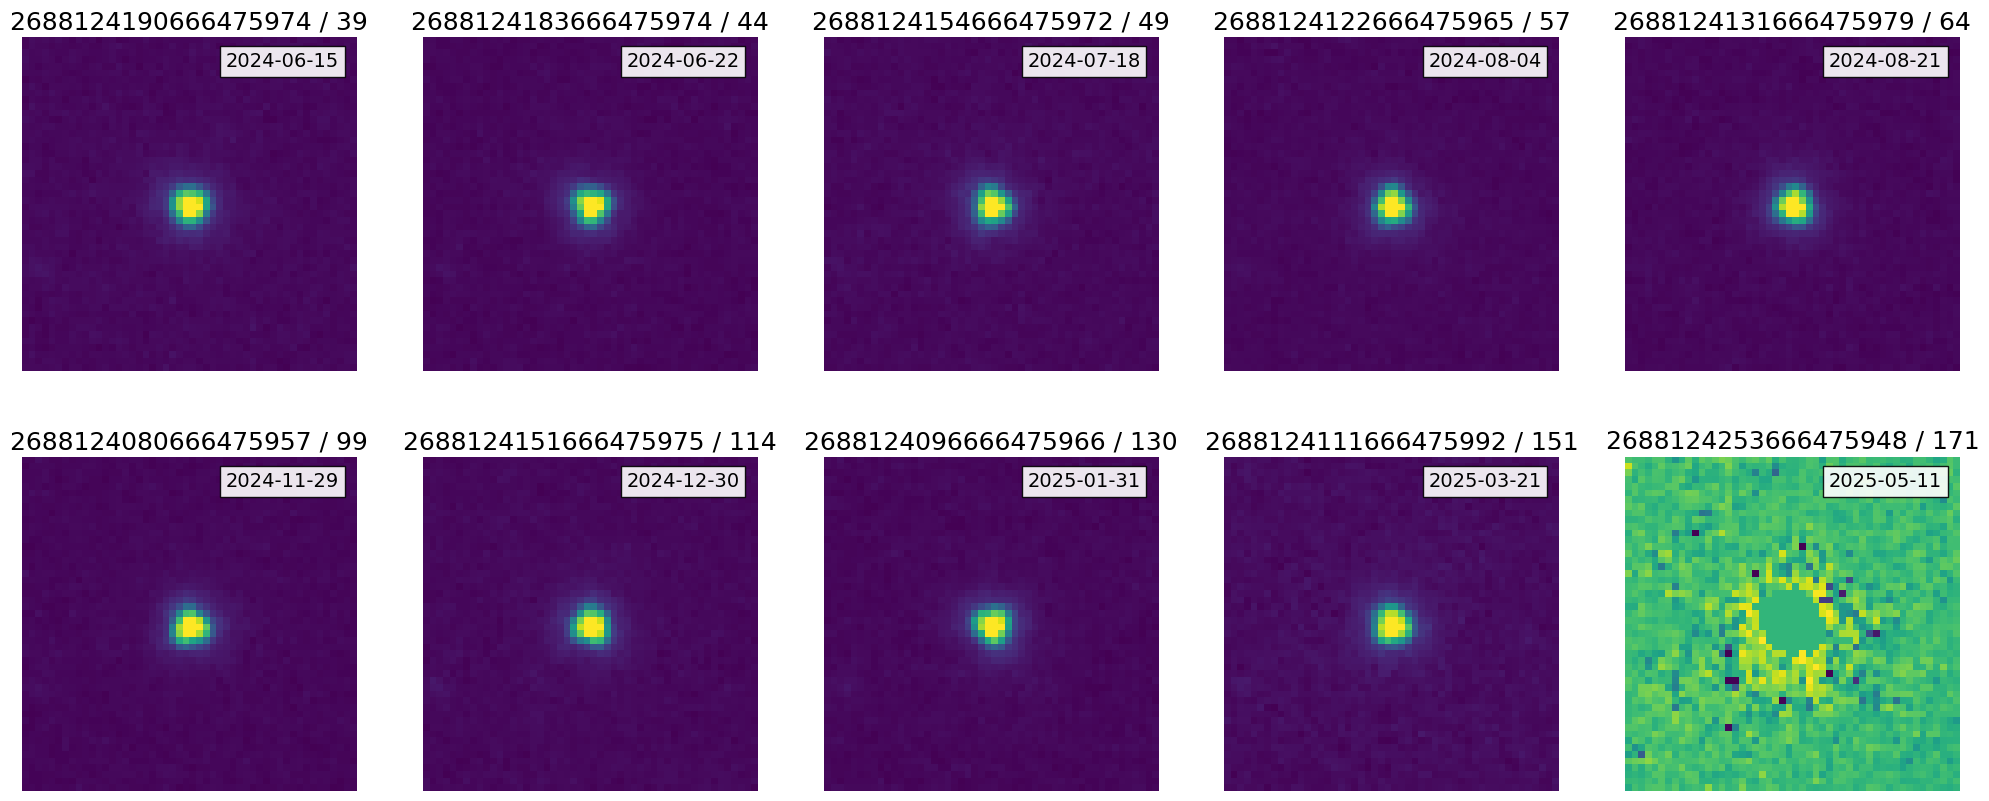

In [8]:
# Cutouts generation ============
subset      = final
cutout_r    = 5 * u.arcsecond # Cutout size (height x weight)
cutout_list = []
coords      = SkyCoord(coords_ra, coords_dec, unit="deg")

for ii in range(len(subset)):
    file_path     = f"{subset['datalabs_path'][ii]}/{subset['file_name'][ii]}"
    hdul          = fits.open(file_path)
    cutout        = Cutout2D(data=hdul[0].data, position = coords, size= cutout_r, wcs=wcs.WCS(hdul[0].header))
    cutout_list.append(cutout)
    hdul.close()


# Plot images ===================
list_title  = [f"{inp['object_id']} / {inp['patch_id_list']}" for inp in subset]
list_date   = [f"{inp['reference_observation_date_time'][0:10]}"    for inp in subset]

plt.figure(figsize=[25,10])

for ii in range(10):
    ax = plt.subplot(2,5,1 + ii)
    ax.imshow(cutout_list[ii].data, cmap='viridis', origin='lower', norm = ImageNormalize(cutout_list[ii].data, interval=PercentileInterval(99.5), stretch=AsinhStretch()))
    ax.set_title(list_title[ii], fontsize=18)
    
    x, y, w, h = 30, 40, 0, 0  
    ax.text(x, y + h + 5, list_date[ii],fontsize=14,bbox=dict(facecolor='white', alpha=0.9))
    ax.axis('off')

plt.show()
    
# To export the image as png:
# png_name = 'cutout_example.png'
# plt.savefig(png_name, dpi=300, bbox_inches='tight', pad_inches=0)    

## Intermezzo: MOSAICS + PROCESSING MODE = DEEP


In [9]:
rad      = 0.01/60. # [Degrees]: radius applied to identify observations that cover the sky region where the target source is located.
scols    = """reference_observation_date_time, processing_mode, ra, dec, purpose, release_name, datalabs_path, file_name, filter_name, patch_id_list, observation_id_list"""

query = f"""SELECT {scols}, DISTANCE({coords_ra}, {coords_dec}, ra, dec)*60 AS sep_arcmin
FROM dr1.mosaic_product WHERE INTERSECTS(CIRCLE({coords_ra}, {coords_dec}, {rad}), fov)=1
AND instrument_name = 'VIS'
AND processing_mode = 'DEEP'
ORDER BY reference_observation_date_time ASC"""

res = utils.get_query_results(Euclid,query)

ADQL query: 
SELECT reference_observation_date_time, processing_mode, ra, dec, purpose, release_name, datalabs_path, file_name, filter_name, patch_id_list, observation_id_list, DISTANCE(268.8124142787188, 66.6475971869471, ra, dec)*60 AS sep_arcmin
FROM dr1.mosaic_product WHERE INTERSECTS(CIRCLE(268.8124142787188, 66.6475971869471, 0.00016666666666666666), fov)=1
AND instrument_name = 'VIS'
AND processing_mode = 'DEEP'
ORDER BY reference_observation_date_time ASC

INFO: Query finished. [astroquery.utils.tap.core]
Total runtime: 0.8 seconds


reference_observation_date_time,processing_mode,ra,dec,purpose,release_name,datalabs_path,file_name,filter_name,patch_id_list,observation_id_list,sep_arcmin
str22,str4,float64,float64,str17,str6,str42,str80,str3,str36,str99,float64
2024-08-21T16:49:47.45,DEEP,268.9661452729,66.75,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101835788/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101835788-60107B_20250823T055703.839205Z_00.00.fits,VIS,"38,39,44,49,57,64,99,114,130,151,171",2046 2047 2090 2091 2204 2205 2693 2996 2997 3316 3317 5009 5010 5571 6152 6153 6879 6884 7780 7789,7.145856934217854


- reading: /data/euclid_idr1/DR1/R1/MER/101835788/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE101835788-60107B_20250823T055703.839205Z_00.00.fits



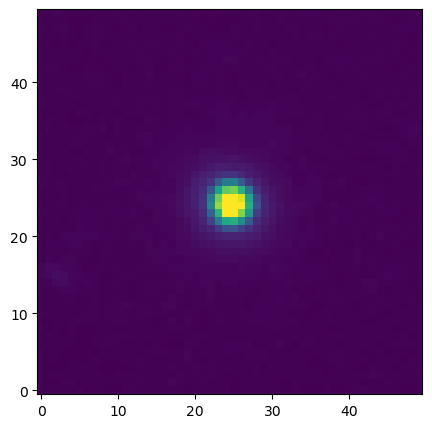

In [10]:
# Cutouts generation ============
subset      = res
cutout_r    = 5 * u.arcsecond # Cutout size (height x weight)

file_path  = f"{subset['datalabs_path'][0]}/{subset['file_name'][0]}"
print(f'- reading: {file_path}')
print()

hdul          = fits.open(file_path)
cutout        = Cutout2D(data=hdul[0].data, position = coords, size= cutout_r, wcs=wcs.WCS(hdul[0].header ))
hdul.close()


# Plot images ===================
plt.figure(figsize=[7,5])

ax = plt.subplot(1,1,1)
ax.imshow(cutout.data, cmap='viridis', origin='lower', norm = ImageNormalize(cutout.data, interval=PercentileInterval(99.5), stretch=AsinhStretch()))

plt.show()

## 2. Create MOSAIC cutouts associated to a list of (Simbad names) DEEP sources


When dealing with lists of input coordinates or source ids, the recommended approach is to first upload the target list to the user space - Please see the accompanning "Astroquery" notebook, and the "Use case 3" in the accompanning "Spectra_visualisation" notebook.

### 2.1: Gather the SIMBAD coordinates

The coordinates of three Galaxies featured in this [Euclid Nearby Galaxies Collage](https://www.cosmos.esa.int/web/euclid/euclid-nearby-galaxies-collage) are obtained using the Astroquery.Simbad package.

Note: these coordinates come from the SIMBAD database and are therefore in epoch J2000. It is likely that the coordinates of these objects in the Euclid observations have changed (slightly) due to their proper motions, but this effect is negligible for this use case.

In [11]:
my_table   = Simbad.query_objects(['PGC 129576', 'PGC 129507', 'PGC 2679728'])
table_name = 'cutouts_tutorial_input'        # Table name at the user space
my_table

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode,user_specified_id,object_number_id
,deg,deg,mas,mas,deg,,,,
object,float64,float64,float32,float32,int16,str1,object,object,int64
LEDA 129576,64.88276666666665,-48.284908333333334,--,--,--,I,2006AJ....131.1163S,PGC 129576,1
LEDA 129507,60.95899112066999,-50.08558912093001,1.6303,1.1664,90,O,2020yCat.1350....0G,PGC 129507,2
LEDA 2679728,274.220275,65.68636388888889,--,--,--,I,2006AJ....131.1163S,PGC 2679728,3


### 2.2: Upload table to the user space

The code below first checks if the user table is already present in the Archive user space.

**Notes:** 
* Please remember to not include special [ADQL characters](https://www.ivoa.net/documents/ADQL/20230418/PR-ADQL-2.1-20230418.pdf) in the table name (e.g., a dot "." or a minus sign "-" can generate problems when trying to access to the user table in the database). We also recommmend to not use capital letters in the table name.
* If the user table already exists in the user space, the code will not overwrite it, but stop the upload.

In [12]:
user       = getpass.getuser()                            # User name
utables    = Euclid.load_tables(only_names=True)                                                                  # Get names of Archive tables
my_utables = [utable.get_qualified_name() for utable in utables if f'user_{user}' in utable.get_qualified_name()] # Extract user table names
print(f'User tables found in the Archive: ')
for my_utable in my_utables:
    print(f'* {my_utable}')
    

fq_name    = f'user_{user}.{table_name}'
if fq_name in my_utables:
    print(f'* Warning: {table_name} exist on the user space - stopping table upload')
else:
    Euclid.upload_table(upload_resource=my_table['main_id', 'ra', 'dec'], table_name = table_name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
User tables found in the Archive: 
* user_hcanovas.cutouts_tutorial_input
* user_hcanovas.helpdesk_EUCSD_881
* user_hcanovas.my_sources_from_file
* user_hcanovas.my_sources_from_file_10
* user_hcanovas.spec_tutorial_input
* user_hcanovas.test_helpdesk_eucsd_881
* Warning: cutouts_tutorial_input exist on the user space - stopping table upload


### 2.3: Cross-match with the MER (DEEP) catalogue

The query below requires ~ 40 seconds to finish. Alternatively, the cross-match operation can be done directly on the "dr1.mosaic_product" table.

In [13]:
query = f"""SELECT my_table.*, mer.right_ascension, mer.declination, mer.object_id, mer.tile_index, mer.patch_id_list AS patch_id_list_original, ESDC_ARRAY_ELEMENT(mer.patch_id_list,1) AS patch_id_list,
mer.flux_detection_total, mer.flux_vis_sersic, DISTANCE(POINT(my_table.ra, my_table.dec), POINT(mer.right_ascension, mer.declination)) AS ang_sep
FROM user_{user}.{table_name} AS my_table
JOIN catalogue.mer_catalogue_deep_survey AS mer
ON DISTANCE(POINT(my_table.ra, my_table.dec), POINT(mer.right_ascension, mer.declination)) < 1./3600."""

res = utils.get_query_results(Euclid, query)

ADQL query: 
SELECT my_table.*, mer.right_ascension, mer.declination, mer.object_id, mer.tile_index, mer.patch_id_list AS patch_id_list_original, ESDC_ARRAY_ELEMENT(mer.patch_id_list,1) AS patch_id_list,
mer.flux_detection_total, mer.flux_vis_sersic, DISTANCE(POINT(my_table.ra, my_table.dec), POINT(mer.right_ascension, mer.declination)) AS ang_sep
FROM user_hcanovas.cutouts_tutorial_input AS my_table
JOIN catalogue.mer_catalogue_deep_survey AS mer
ON DISTANCE(POINT(my_table.ra, my_table.dec), POINT(mer.right_ascension, mer.declination)) < 1./3600.

INFO: Query finished. [astroquery.utils.tap.core]
Total runtime: 44.6 seconds


cutouts_tutorial_input_oid,main_id,ra,dec,right_ascension,declination,object_id,tile_index,patch_id_list_original,patch_id_list,flux_detection_total,flux_vis_sersic,ang_sep
int64,str12,float64,float64,float64,float64,int64,int64,str48,int64,float64,float64,float64
3,LEDA 2679728,274.220275,65.68636388888889,274.2205435971991,65.68640299764408,2742205435656864029,101833458,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",38,2187.6357421875,2007.109375,0.00011730129532680488
2,LEDA 129507,60.95899112066999,-50.08558912093001,60.95890382232392,-50.08562875297623,-609589038500856287,101277682,"(62, 67, 71, 74, 78, 107, 111, 115, 123, 126, 0)",62,3656.37451171875,2911.339111328125,6.861706930328145e-05
1,LEDA 129576,64.88276666666665,-48.284908333333334,64.88274119244458,-48.28491398217191,-648827411482849139,101284314,"(62, 67, 71, 74, 78, 107, 111, 115, 123, 126, 0)",62,1975.3909912109375,2001.632080078125,1.7867672354565097e-05


### 2.4 - Find the associated MOSAIC VIS images

**Notes:**
* In this case, the ADQL syntax differs slightly from previous examples. It uses a ```JOIN ... ON ... INTERSECTS()``` construct, which is analogous to the syntax employed for cross-matching catalogues using ```JOIN ... ON ... DISTANCE()```.

* **Important**: 
    * There are two pointings that include observations of the object LEDA 129507. The tile_index associated with this source in the MER catalogue is 101277682. However, the dr1.mosaic_product table reveals that two different files contain observations of this source, with tile_index values 101277681 and 101277682.

    * The dist_cent field computed in the ADQL query represents the angular distance between the object and the center of each MOSAIC observation. As expected, the observation in which the source lies closest to the image center corresponds to the same tile_index (101277682) listed in the MER catalogue.
    
    * Multiple observations can happen and users are advised to check for this.

In [14]:
rad        = 1/60. # [Degrees]: radius applied to identify observations that cover the sky region where the target source is located.
scols      = ['first_observation_date_time', 'reference_observation_date_time', 'last_observation_date_time', 'processing_mode', 'purpose', 'release_name', 
              'datalabs_path', 'file_name', 'filter_name', 'patch_id_list', 'tile_index']
scols      = [f'mosaic.{inp}' for inp in scols]
scols      = ",".join(scols)

instrument = 'VIS'

query = f"""SELECT my_table.*, {scols}, DISTANCE(my_table.ra, my_table.dec, mosaic.ra, mosaic.dec) AS dist_cent
FROM dr1.mosaic_product AS mosaic
JOIN user_{user}.{table_name} AS my_table
  ON INTERSECTS(CIRCLE(my_table.ra, my_table.dec, {rad}), fov)=1
WHERE instrument_name = '{instrument}'
AND processing_mode = 'DEEP'
ORDER BY my_table.main_id
"""
res = utils.get_query_results(Euclid, query)

ADQL query: 
SELECT my_table.*, mosaic.first_observation_date_time,mosaic.reference_observation_date_time,mosaic.last_observation_date_time,mosaic.processing_mode,mosaic.purpose,mosaic.release_name,mosaic.datalabs_path,mosaic.file_name,mosaic.filter_name,mosaic.patch_id_list,mosaic.tile_index, DISTANCE(my_table.ra, my_table.dec, mosaic.ra, mosaic.dec) AS dist_cent
FROM dr1.mosaic_product AS mosaic
JOIN user_hcanovas.cutouts_tutorial_input AS my_table
  ON INTERSECTS(CIRCLE(my_table.ra, my_table.dec, 0.016666666666666666), fov)=1
WHERE instrument_name = 'VIS'
AND processing_mode = 'DEEP'
ORDER BY my_table.main_id


INFO: Query finished. [astroquery.utils.tap.core]
Total runtime: 1.4 seconds


cutouts_tutorial_input_oid,main_id,ra,dec,first_observation_date_time,reference_observation_date_time,last_observation_date_time,processing_mode,purpose,release_name,datalabs_path,file_name,filter_name,patch_id_list,tile_index,dist_cent
int64,str12,float64,float64,str23,str23,str23,str4,str17,str6,str42,str80,str3,str36,int64,float64
2,LEDA 129507,60.95899112066999,-50.08558912093001,2024-08-14T15:21:27.831,2024-09-27T09:32:34.263,2025-01-22T16:32:25.546,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101277681/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101277681-6275AF_20251014T045143.237068Z_00.00.fits,VIS,"62,67,71,74,78,107,111,115,123,126",101277681,0.16089100267377626
2,LEDA 129507,60.95899112066999,-50.08558912093001,2024-08-14T16:14:45.837,2024-09-27T15:22:58.805,2025-01-22T16:32:25.546,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101277682/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101277682-193D3C_20251012T011937.040048Z_00.00.fits,VIS,"62,67,71,74,78,107,111,115,123,126",101277682,0.1411585512313934
1,LEDA 129576,64.88276666666665,-48.284908333333334,2024-08-15T15:59:07.993,2024-09-28T05:06:03.895,2025-01-23T17:09:53.71,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101284314/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101284314-2AA6D5_20250930T191200.818696Z_00.00.fits,VIS,"62,67,71,74,78,107,111,115,123,126",101284314,0.0914392843179849
3,LEDA 2679728,274.220275,65.68636388888889,2024-06-12T23:23:56.896,2024-11-29T06:52:13.835,2025-05-11T12:45:28.072,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101833458/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101833458-52BB56_20250828T142405.645231Z_00.00.fits,VIS,"38,39,44,49,57,64,99,114,130,151,171",101833458,0.07142374461599263


0 - reading: /data/euclid_idr1/DR1/R1/MER/101277682/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE101277682-193D3C_20251012T011937.040048Z_00.00.fits
1 - reading: /data/euclid_idr1/DR1/R1/MER/101284314/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE101284314-2AA6D5_20250930T191200.818696Z_00.00.fits
2 - reading: /data/euclid_idr1/DR1/R1/MER/101833458/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE101833458-52BB56_20250828T142405.645231Z_00.00.fits


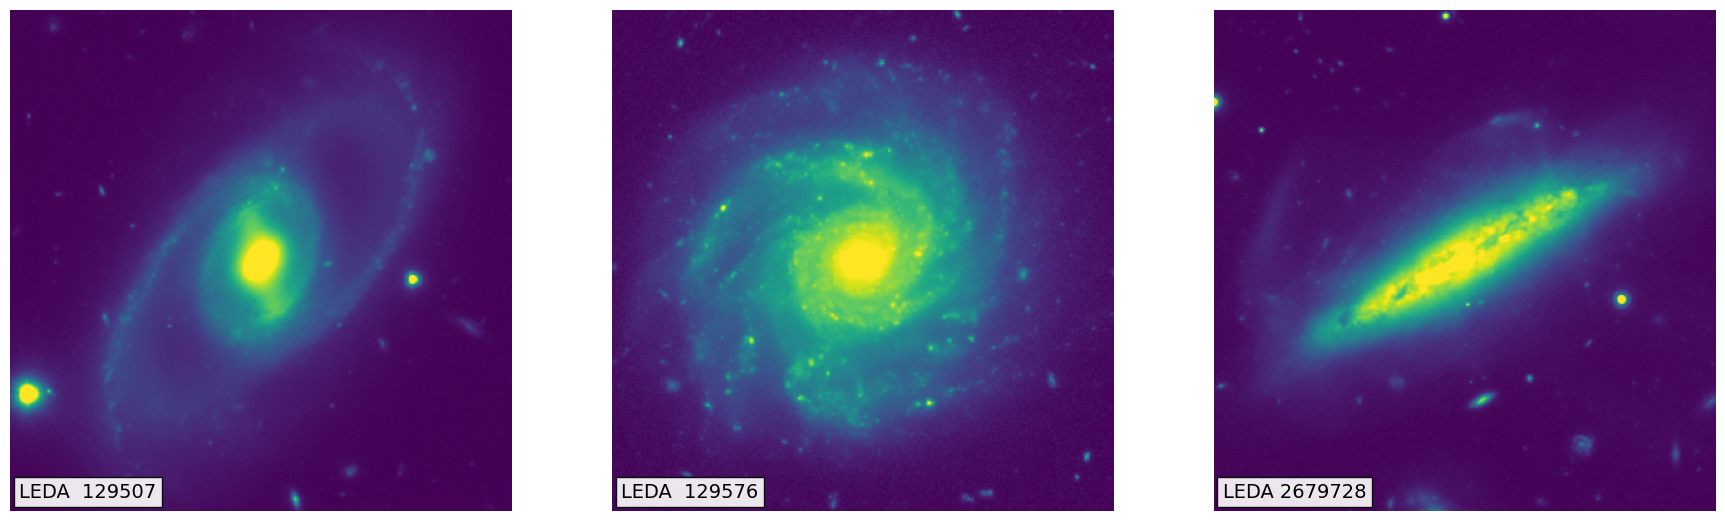

In [15]:
# Cutouts generation ============
subset      = res[1:] # (exclusing the first row to avoid duplication)
cutout_r    = 40 * u.arcsecond # Cutout size (height x weight)
cutout_list = []

coords      = [SkyCoord(inp['ra']*u.deg, inp['dec']* u.deg)   for inp in subset]
for ii in range(len(subset)):
    file_path  = f"{subset['datalabs_path'][ii]}/{subset['file_name'][ii]}"
    print(f'{ii} - reading: {file_path}')
    
    hdul          = fits.open(file_path)
    cutout        = Cutout2D(data=hdul[0].data, position = coords[ii], size= cutout_r, wcs=wcs.WCS(hdul[0].header))
    cutout_list.append(cutout)
    hdul.close()
    

list_title  = [f"{inp}"                                       for inp in range(len(subset))]
list_date   = [f"{inp['reference_observation_date_time']}"    for inp in subset]

# Plot images ===================
plt.figure(figsize=[22,7])

for ii in range(len(subset)):
    ax = plt.subplot(1,len(subset),1 + ii)
    ax.imshow(cutout_list[ii].data, cmap='viridis', origin='lower', norm = ImageNormalize(cutout_list[ii].data, interval=PercentileInterval(99.), stretch=AsinhStretch()))
    
    x, y, w, h = 7, 5, 0, 0
    ax.text(x, y + h + 5, subset['main_id'][ii],fontsize=14,bbox=dict(facecolor='white', alpha=0.9))
    ax.axis('off')

plt.show()

## 3. Create MOSAIC cutouts associated to a list of sources included in the DEEP catalogue

In this use case, it is not always necessary to upload the table list to the user space. Instead, the query used to generate the input list can be inserted inside am ADQL [WITH](https://www.ivoa.net/Documents/ADQL/20231215/REC-ADQL-2.1.html#tth_sEc4.5.1) operator as detailed below. If the. input source list contains many (say >10,000) sources, then we suggest to first upload that list to the user space as in the previous example.

### 3.1: Gather the MER source list



In [16]:
tile_index = 101832848

query_1 = f"""SELECT right_ascension, declination, object_id, tile_index, patch_id_list, flux_detection_total, flux_vis_sersic, flux_segmentation, ellipticity
FROM catalogue.mer_catalogue_deep_survey AS mer
WHERE tile_index = {101832848}
AND NULLIF(flux_vis_sersic, 'NaN') > 1000.
AND ellipticity > 0.15"""

res = utils.get_query_results(Euclid, query_1)

ADQL query: 
SELECT right_ascension, declination, object_id, tile_index, patch_id_list, flux_detection_total, flux_vis_sersic, flux_segmentation, ellipticity
FROM catalogue.mer_catalogue_deep_survey AS mer
WHERE tile_index = 101832848
AND NULLIF(flux_vis_sersic, 'NaN') > 1000.
AND ellipticity > 0.15

INFO: Query finished. [astroquery.utils.tap.core]
Total runtime: 0.9 seconds


right_ascension,declination,object_id,tile_index,patch_id_list,flux_detection_total,flux_vis_sersic,flux_segmentation,ellipticity
float64,float64,int64,int64,str48,float64,float64,float64,float64
267.7001976590989,65.59850589774352,2677001976655985058,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",1584.00830078125,1830.094482421875,1588.6610107421875,0.2648807466030121
267.5550239799224,65.46000528121264,2675550239654600052,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",5388.87646484375,3676.042724609375,5464.8798828125,0.18014690279960632
267.40916552638134,65.61001315301267,2674091655656100131,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2884.8876953125,2871.361572265625,2948.747314453125,0.21717795729637146
267.8068037379451,65.47659575781641,2678068037654765957,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",1948.9942626953125,1801.0985107421875,1937.952392578125,0.30191653966903687
267.35883993609775,65.43017964469828,2673588399654301796,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2548.087890625,2401.765380859375,2568.68505859375,0.176693394780159
267.77019767808497,65.38281373942439,2677701976653828137,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",6488.37841796875,7101.666015625,6510.6103515625,0.22526249289512634
267.75661175553546,65.53781092682195,2677566117655378109,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",574.0881958007812,1615.0821533203125,552.7171630859375,0.6944206953048706
267.76423640637967,65.56813269392855,2677642364655681326,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",4092.239501953125,4090.7763671875,4206.61767578125,0.25257012248039246
267.71522461638216,65.6004170160536,2677152246656004170,101832848,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2565.196533203125,2510.470703125,2536.369384765625,0.22771377861499786


In [17]:
rad      = 20/3600. # [Degrees]: radius applied to identify observations that cover the sky region where the target source is located. Watch out! Errors can appear if the source is too close to the image edges (it happens when rad increases)

query = f"""WITH my_table AS ({query_1})

SELECT my_table.*, mosaic.first_observation_date_time, mosaic.reference_observation_date_time, mosaic.last_observation_date_time, mosaic.processing_mode, 
mosaic.purpose, mosaic.release_name, mosaic.datalabs_path, mosaic.file_name, mosaic.filter_name, mosaic.tile_index, DISTANCE(my_table.right_ascension, my_table.declination, mosaic.ra, mosaic.dec)*60 AS dist
FROM my_table
JOIN dr1.mosaic_product AS mosaic
  ON INTERSECTS(CIRCLE(my_table.right_ascension, my_table.declination, {rad}), mosaic.fov)=1
WHERE mosaic.instrument_name = 'VIS'
AND mosaic.processing_mode = 'DEEP'
AND mosaic.tile_index = {tile_index}
ORDER BY my_table.object_id

"""
res = utils.get_query_results(Euclid, query)

ADQL query: 
WITH my_table AS (SELECT right_ascension, declination, object_id, tile_index, patch_id_list, flux_detection_total, flux_vis_sersic, flux_segmentation, ellipticity
FROM catalogue.mer_catalogue_deep_survey AS mer
WHERE tile_index = 101832848
AND NULLIF(flux_vis_sersic, 'NaN') > 1000.
AND ellipticity > 0.15)

SELECT my_table.*, mosaic.first_observation_date_time, mosaic.reference_observation_date_time, mosaic.last_observation_date_time, mosaic.processing_mode, 
mosaic.purpose, mosaic.release_name, mosaic.datalabs_path, mosaic.file_name, mosaic.filter_name, mosaic.tile_index, DISTANCE(my_table.right_ascension, my_table.declination, mosaic.ra, mosaic.dec)*60 AS dist
FROM my_table
JOIN dr1.mosaic_product AS mosaic
  ON INTERSECTS(CIRCLE(my_table.right_ascension, my_table.declination, 0.005555555555555556), mosaic.fov)=1
WHERE mosaic.instrument_name = 'VIS'
AND mosaic.processing_mode = 'DEEP'
AND mosaic.tile_index = 101832848
ORDER BY my_table.object_id



INFO: Query finished. [

right_ascension,declination,tile_index,flux_detection_total,flux_segmentation,flux_vis_sersic,patch_id_list,object_id,ellipticity,first_observation_date_time,reference_observation_date_time,last_observation_date_time,processing_mode,purpose,release_name,datalabs_path,file_name,filter_name,tile_index_1,dist
float64,float64,int64,float64,float64,float64,str48,int64,float64,str23,str23,str23,str4,str17,str6,str42,str80,str3,int64,float64
267.2724247680601,65.42411581644174,101832848,7223.072265625,7641.20458984375,7208.70361328125,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2672724247654241158,0.15769840776920319,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,7.674303564207468
267.35883993609775,65.43017964469828,101832848,2548.087890625,2568.68505859375,2401.765380859375,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2673588399654301796,0.176693394780159,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,5.80881597174602
267.401739243937,65.61344716629941,101832848,1447.540283203125,1458.611572265625,1444.285888671875,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2674017392656134471,0.3681388795375824,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,7.416533882659406
267.40916552638134,65.61001315301267,101832848,2884.8876953125,2948.747314453125,2871.361572265625,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2674091655656100131,0.21717795729637146,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,7.154826941173655
267.43255282858485,65.4237112136986,101832848,3715.25146484375,3759.74462890625,3602.6396484375,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2674325528654237112,0.15971489250659943,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,5.073280625319538
267.493536112857,65.59495560428874,101832848,3644.950439453125,3690.699462890625,2690.3740234375,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2674935361655949556,0.24199052155017853,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,5.7361292095899525
267.5315787459456,65.42191811766207,101832848,1165.96728515625,1137.765380859375,1049.541259765625,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2675315787654219181,0.21067722141742706,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,4.693259508393886
267.5550239799224,65.46000528121264,101832848,5388.87646484375,5464.8798828125,3676.042724609375,"(38, 39, 44, 49, 57, 64, 99, 114, 130, 151, 171)",2675550239654600052,0.18014690279960632,2024-06-13T08:57:41.959,2024-12-29T18:15:56.715,2025-05-12T10:20:42.218,DEEP,DATA_RELEASE_DEEP,DR1_R1,/data/euclid_idr1/DR1/R1/MER/101832848/VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE101832848-89A871_20250828T201044.997028Z_00.00.fits,VIS,101832848,2.550273809

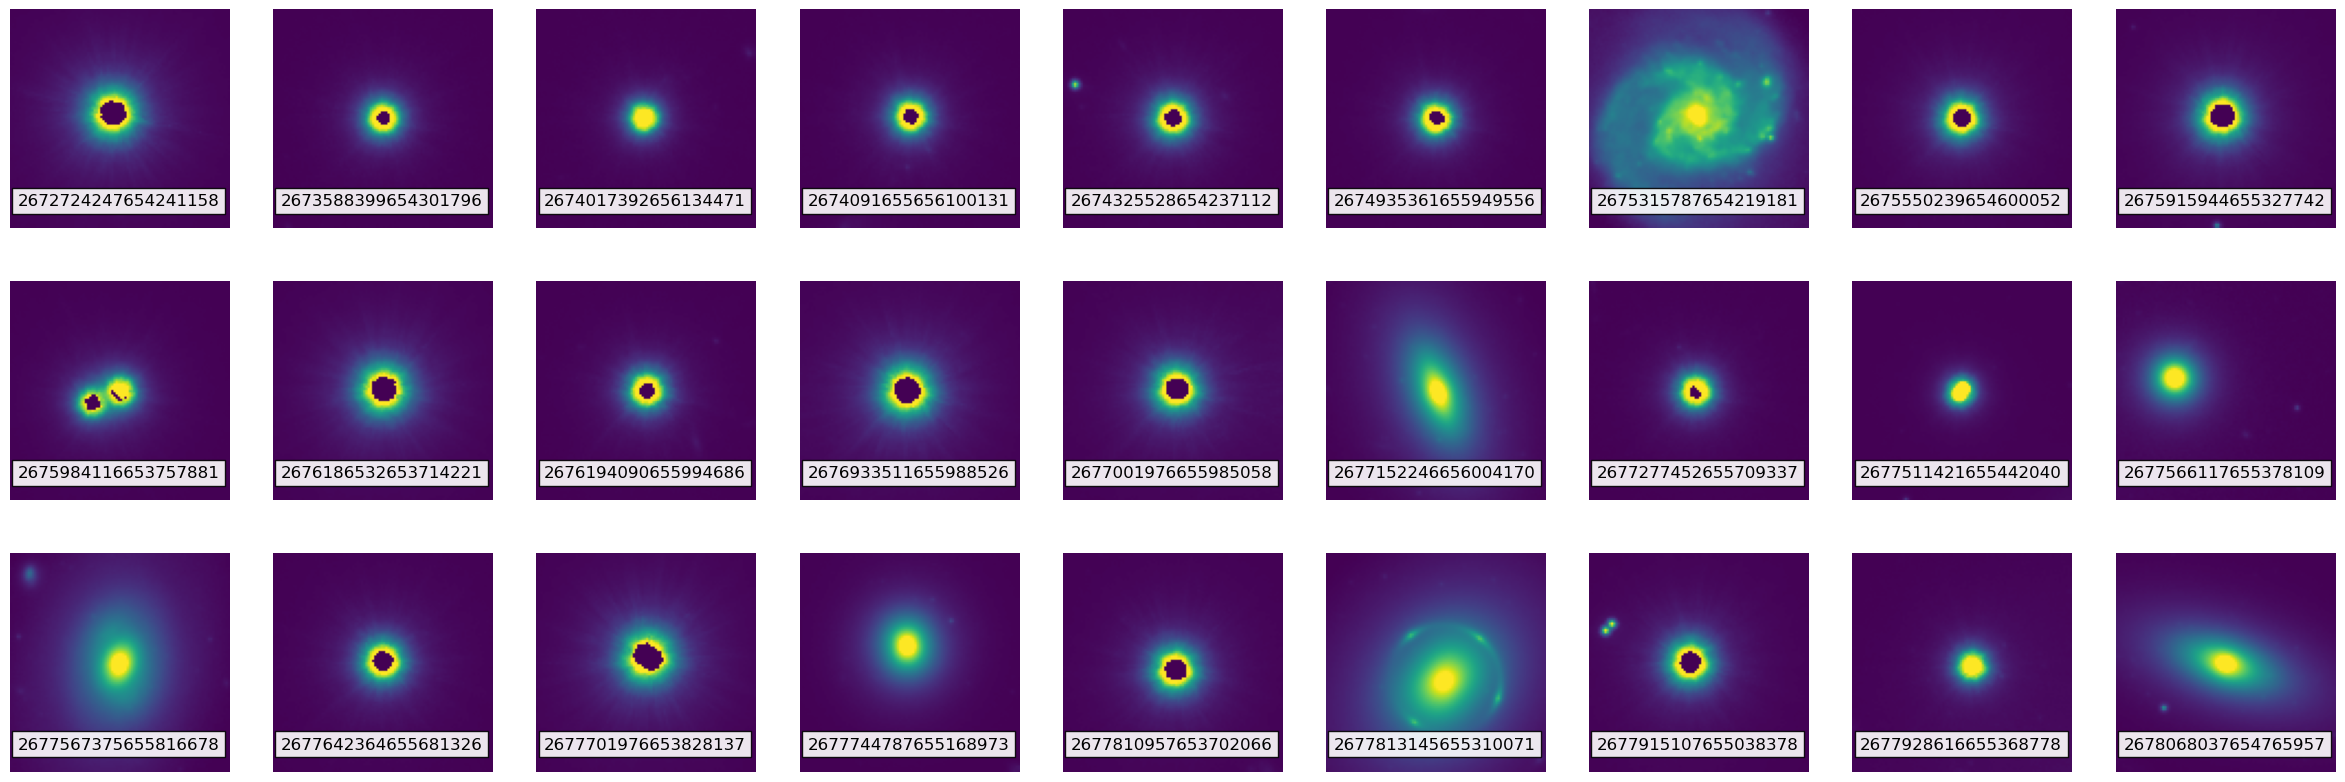

In [18]:
# Cutouts generation ============
subset      = res
cutout_r    = 10 * u.arcsecond # Cutout size (height x weight)
cutout_list = []

list_title  = [f"{inp}"                                       for inp in range(len(subset))]
list_date   = [f"{inp['reference_observation_date_time']}"    for inp in subset]
coords      = [SkyCoord(inp['right_ascension']*u.deg, inp['declination']* u.deg)   for inp in subset]


for ii in range(len(subset)):
    file_path  = f"{subset['datalabs_path'][ii]}/{subset['file_name'][ii]}"
    
    hdul          = fits.open(file_path)
    data          = hdul[0].data
    header        = hdul[0].header
    cutout        = Cutout2D(mode = 'partial', fill_value = 0.0, data=data, position = coords[ii], size= cutout_r, wcs=wcs.WCS(header))    
    cutout_list.append(cutout)
    hdul.close()

# Plot images ===================
plt.figure(figsize=[30,10])

for ii in range(len(subset)):
    ax = plt.subplot(3,9,1 + ii)    
    ax.imshow(cutout_list[ii].data, cmap='viridis', origin='lower', norm = ImageNormalize(cutout_list[ii].data, interval=PercentileInterval(99.), stretch=AsinhStretch()))
    
    x, y, w, h = 3, 5, 0, 0
    ax.text(x, y + h + 5, subset['object_id'][ii],fontsize=12,bbox=dict(facecolor='white', alpha=0.9))
    ax.axis('off')

plt.show()